In [1]:
import os
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

from skimage.measure import label, regionprops
from skimage.color import gray2rgb
from skimage.segmentation import find_boundaries

In [2]:
# Example paths — change these to your actual files
manual_mask_path = "mask_output_latest_version/671463s2d20250701 2_mask.tiff"
auto_mask_path   = "cellpose_sam_results/671463s2d20250701_sam_masks.tif"

# Optional: raw image path if you want overlay on original image
raw_image_path = None   # e.g. "resonant/your_image.tiff"

In [3]:
#helper function 

def load_mask(path):
    """
    Load mask from tif/tiff/png-like file.
    """
    arr = tiff.imread(path)
    arr = np.squeeze(arr)
    return arr


def ensure_instance_labels(mask):
    """
    If mask is binary, convert to connected-component labels.
    If already labeled, keep as is.
    """
    mask = np.asarray(mask)

    unique_vals = np.unique(mask)

    # Case 1: binary mask
    if set(unique_vals).issubset({0, 1}):
        labeled = label(mask > 0)
        return labeled

    # Case 2: already labeled instance mask
    # We assume >0 are ROI IDs
    return mask.astype(np.int32)


def compute_iou(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return inter / union


def compute_dice(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    denom = mask1.sum() + mask2.sum()
    if denom == 0:
        return 0.0
    return 2 * inter / denom


def build_binary_dict(label_img):
    """
    Returns dictionary: roi_id -> binary mask
    """
    ids = np.unique(label_img)
    ids = ids[ids > 0]
    return {roi_id: (label_img == roi_id) for roi_id in ids}

In [4]:
#load masks 


manual_mask_raw = load_mask(manual_mask_path)
auto_mask_raw   = load_mask(auto_mask_path)

manual_labels = ensure_instance_labels(manual_mask_raw)
auto_labels   = ensure_instance_labels(auto_mask_raw)

print("Manual mask shape:", manual_labels.shape)
print("Auto mask shape:", auto_labels.shape)

print("Manual ROI count:", len(np.unique(manual_labels)) - 1)
print("Auto ROI count:", len(np.unique(auto_labels)) - 1)

Manual mask shape: (512, 512)
Auto mask shape: (512, 512)
Manual ROI count: 36
Auto ROI count: 42


In [5]:
pwd


'/scratch/user/s4906996/Cellpose SAM'

In [6]:
#building ROI masks
manual_rois = build_binary_dict(manual_labels)
auto_rois   = build_binary_dict(auto_labels)

manual_ids = list(manual_rois.keys())
auto_ids   = list(auto_rois.keys())

In [7]:
#matching each ROI with the best ROI usinf IOU 
IOU_THRESHOLD = 0.3

results = []
matched_auto_ids = set()

for m_id, m_mask in manual_rois.items():
    best_auto_id = None
    best_iou = 0.0
    best_dice = 0.0

    for a_id, a_mask in auto_rois.items():
        iou = compute_iou(m_mask, a_mask)

        if iou > best_iou:
            best_iou = iou
            best_auto_id = a_id
            best_dice = compute_dice(m_mask, a_mask)

    if best_iou >= IOU_THRESHOLD:
        classification = "Hit"
        matched_auto_ids.add(best_auto_id)
    else:
        classification = "Miss"
        best_auto_id = None
        best_dice = 0.0

    results.append({
        "manual_roi": m_id,
        "matched_auto_roi": best_auto_id,
        "classification": classification,
        "iou": best_iou,
        "dice": best_dice
    })

results_df = pd.DataFrame(results)
results_df

,manual_roi,matched_auto_roi,classification,iou,dice
0,1,7.0,Hit,0.783914,0.878870
1,2,8.0,Hit,0.723026,0.839252
2,3,10.0,Hit,0.785129,0.879633
3,4,11.0,Hit,0.829920,0.907056
4,5,12.0,Hit,0.653139,0.790180
5,6,13.0,Hit,0.716620,0.834920
6,7,NaN,Miss,0.184239,0.000000
7,8,NaN,Miss,0.016952,0.000000
8,9,16.0,Hit,0.514263,0.679226
9,10,17.0,Hit,0.447148,0.617972


In [8]:
#Finding False alarms

false_alarm_rows = []

for a_id in auto_ids:
    if a_id not in matched_auto_ids:
        false_alarm_rows.append({
            "manual_roi": None,
            "matched_auto_roi": a_id,
            "classification": "False Alarm",
            "iou": 0.0,
            "dice": 0.0
        })

false_alarm_df = pd.DataFrame(false_alarm_rows)

display(results_df)
display(false_alarm_df)

print("Hits:", (results_df["classification"] == "Hit").sum())
print("Misses:", (results_df["classification"] == "Miss").sum())
print("False Alarms:", len(false_alarm_df))

,manual_roi,matched_auto_roi,classification,iou,dice
0,1,7.0,Hit,0.783914,0.878870
1,2,8.0,Hit,0.723026,0.839252
2,3,10.0,Hit,0.785129,0.879633
3,4,11.0,Hit,0.829920,0.907056
4,5,12.0,Hit,0.653139,0.790180
5,6,13.0,Hit,0.716620,0.834920
6,7,NaN,Miss,0.184239,0.000000
7,8,NaN,Miss,0.016952,0.000000
8,9,16.0,Hit,0.514263,0.679226
9,10,17.0,Hit,0.447148,0.617972


,manual_roi,matched_auto_roi,classification,iou,dice
0,None,1,False Alarm,0.0,0.0
1,None,2,False Alarm,0.0,0.0
2,None,3,False Alarm,0.0,0.0
3,None,4,False Alarm,0.0,0.0
4,None,5,False Alarm,0.0,0.0
5,None,6,False Alarm,0.0,0.0
6,None,9,False Alarm,0.0,0.0
7,None,14,False Alarm,0.0,0.0
8,None,18,False Alarm,0.0,0.0
9,None,22,False Alarm,0.0,0.0


Hits: 29
Misses: 7
False Alarms: 13


In [9]:
#summary of counts 
n_hits = (results_df["classification"] == "Hit").sum()
n_miss = (results_df["classification"] == "Miss").sum()
n_fa   = len(false_alarm_df)

print(f"Manual ROIs: {len(manual_ids)}")
print(f"Auto ROIs:   {len(auto_ids)}")
print(f"Hits:        {n_hits}")
print(f"Misses:      {n_miss}")
print(f"False Alarms:{n_fa}")

Manual ROIs: 36
Auto ROIs:   42
Hits:        29
Misses:      7
False Alarms:13


In [10]:
#colour coded masks 
h, w = manual_labels.shape
color_mask = np.zeros((h, w, 3), dtype=np.uint8)

# Hits and Misses are based on MANUAL ROIs
for _, row in results_df.iterrows():
    m_id = row["manual_roi"]
    cls = row["classification"]
    m_mask = manual_rois[m_id]

    if cls == "Hit":
        color_mask[m_mask] = [0, 255, 0]   # Green
    elif cls == "Miss":
        color_mask[m_mask] = [255, 0, 0]   # Red

# False alarms are based on AUTO ROIs
for _, row in false_alarm_df.iterrows():
    a_id = row["matched_auto_roi"]
    a_mask = auto_rois[a_id]
    color_mask[a_mask] = [0, 0, 255]       # Blue

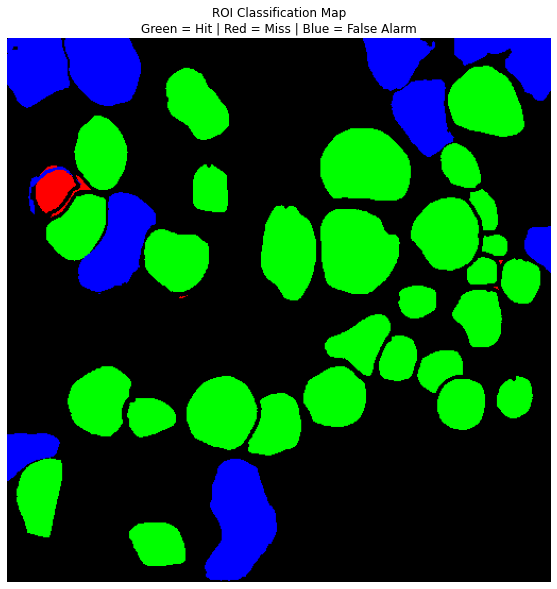

In [11]:
plt.figure(figsize=(10, 10))
plt.imshow(color_mask)
plt.title("ROI Classification Map\nGreen = Hit | Red = Miss | Blue = False Alarm")
plt.axis("off")
plt.show()

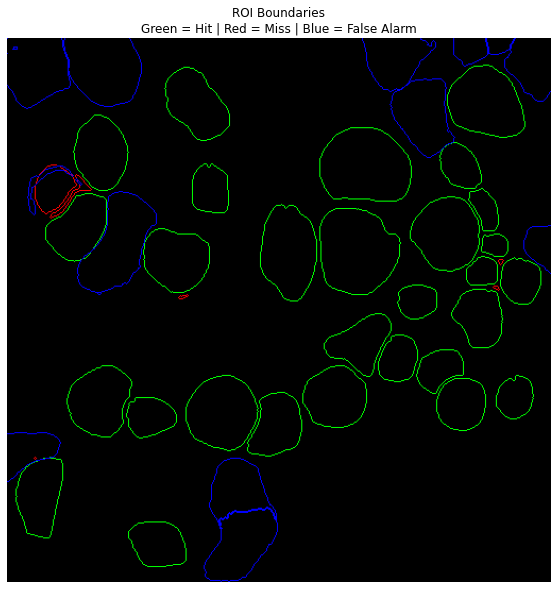

In [12]:
#only showing boundaries
boundary_vis = np.zeros((h, w, 3), dtype=np.uint8)

for _, row in results_df.iterrows():
    m_id = row["manual_roi"]
    cls = row["classification"]
    m_mask = manual_rois[m_id]
    boundary = find_boundaries(m_mask, mode="outer")

    if cls == "Hit":
        boundary_vis[boundary] = [0, 255, 0]
    elif cls == "Miss":
        boundary_vis[boundary] = [255, 0, 0]

for _, row in false_alarm_df.iterrows():
    a_id = row["matched_auto_roi"]
    a_mask = auto_rois[a_id]
    boundary = find_boundaries(a_mask, mode="outer")
    boundary_vis[boundary] = [0, 0, 255]

plt.figure(figsize=(10, 10))
plt.imshow(boundary_vis)
plt.title("ROI Boundaries\nGreen = Hit | Red = Miss | Blue = False Alarm")
plt.axis("off")
plt.show()